In [ ]:
import pandas as pd

df = pd.read_csv('data/whoop_data.csv')

In [17]:
pd.set_option('display.max_columns', None)

df.head()

,Cycle start time,Cycle end time,Cycle timezone,Recovery score %,Resting heart rate (bpm),Heart rate variability (ms),Skin temp (celsius),Blood oxygen %,Day Strain,Energy burned (cal),Max HR (bpm),Average HR (bpm),Sleep onset,Wake onset,Sleep performance %,Respiratory rate (rpm),Asleep duration (min),In bed duration (min),Light sleep duration (min),Deep (SWS) duration (min),REM duration (min),Awake duration (min),Sleep need (min),Sleep debt (min),Sleep efficiency %
0,8/24/2023 0:09,NaN,UTC-04:00,66.0,51.0,55.0,33.50,97.86,NaN,NaN,NaN,NaN,8/24/2023 0:09,8/24/2023 8:15,86.0,15.2,431.0,484.0,170.0,97.0,164.0,53.0,499.0,23.0,89.0
1,8/22/2023 23:13,8/24/2023 0:09,UTC-04:00,89.0,48.0,60.0,33.07,97.89,12.6,2669.0,137.0,68.0,8/22/2023 23:13,8/23/2023 8:10,92.0,15.0,455.0,536.0,201.0,90.0,164.0,81.0,496.0,29.0,84.0
2,8/21/2023 23:24,8/22/2023 23:13,UTC-04:00,80.0,47.0,57.0,32.57,96.21,10.6,2333.0,160.0,67.0,8/21/2023 23:24,8/22/2023 8:20,90.0,15.3,470.0,531.0,274.0,64.0,132.0,61.0,520.0,38.0,88.0
3,8/21/2023 0:53,8/21/2023 23:24,UTC-04:00,68.0,50.0,54.0,33.51,97.25,13.7,2630.0,167.0,69.0,8/21/2023 0:53,8/21/2023 8:55,83.0,14.6,440.0,478.0,289.0,73.0,78.0,38.0,529.0,38.0,92.0
4,8/19/2023 23:55,8/21/2023 0:53,UTC-04:00,49.0,54.0,50.0,32.60,97.14,15.1,3153.0,168.0,73.0,8/19/2023 23:55,8/20/2023 8:39,83.0,15.7,448.0,523.0,249.0,59.0,140.0,75.0,542.0,45.0,85.0


## HRV + is better

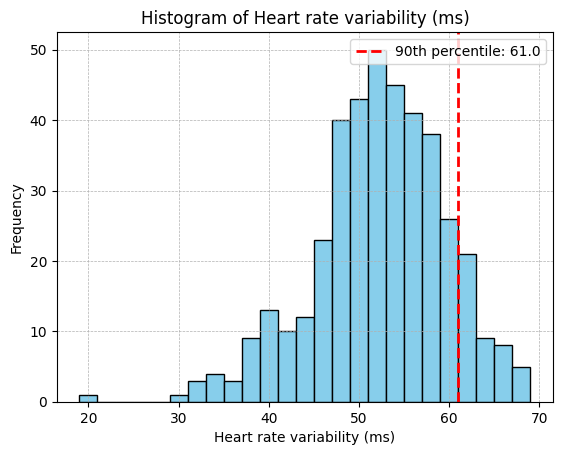

In [25]:
import numpy as np
import matplotlib.pyplot as plt

threshold = df['Heart rate variability (ms)'].quantile(0.90)
threshold

plt.hist(df['Heart rate variability (ms)'], bins=25, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'90th percentile: {threshold}')
plt.title('Histogram of Heart rate variability (ms)')
plt.xlabel('Heart rate variability (ms)')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


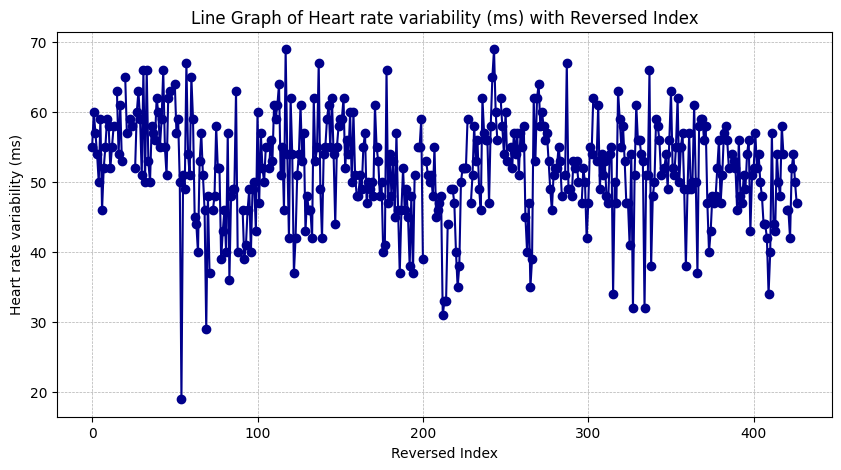

In [7]:
# Create a line graph with reversed order for x-axis (index)
plt.figure(figsize=(10,5))
plt.plot(df.index[::-1], df['Heart rate variability (ms)'][::-1], '-o', color='darkblue')
plt.title('Line Graph of Heart rate variability (ms) with Reversed Index')
plt.xlabel('Reversed Index')
plt.ylabel('Heart rate variability (ms)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [21]:
threshold = df['Heart rate variability (ms)'].quantile(0.9)
threshold

61.0

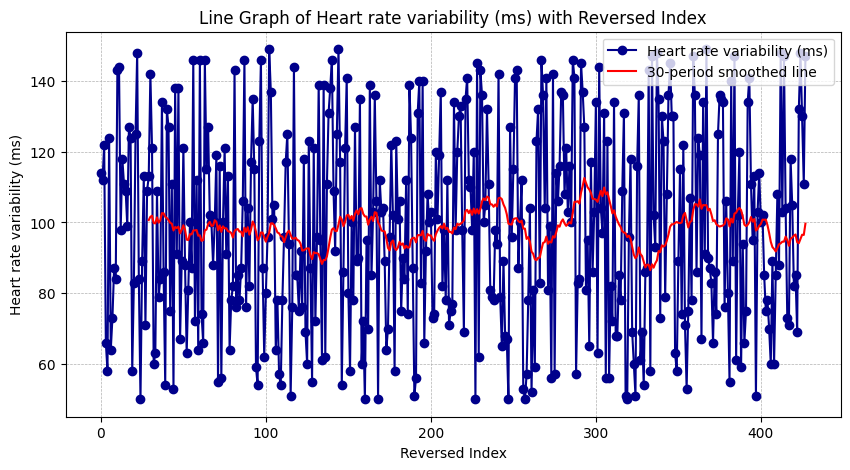

In [43]:
# Calculate the 30-period rolling average for "Heart rate variability (ms)"
rolling_avg = df['Heart rate variability (ms)'].rolling(window=30).mean()

# Create a line graph with reversed order for x-axis (index)
plt.figure(figsize=(10,5))
plt.plot(df.index[::-1], df['Heart rate variability (ms)'][::-1], '-o', color='darkblue', label='Heart rate variability (ms)')
plt.plot(df.index[::-1], rolling_avg[::-1], '-', color='red', label='30-period smoothed line')
plt.title('Line Graph of Heart rate variability (ms) with Reversed Index')
plt.xlabel('Reversed Index')
plt.ylabel('Heart rate variability (ms)')
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


## HR Variability

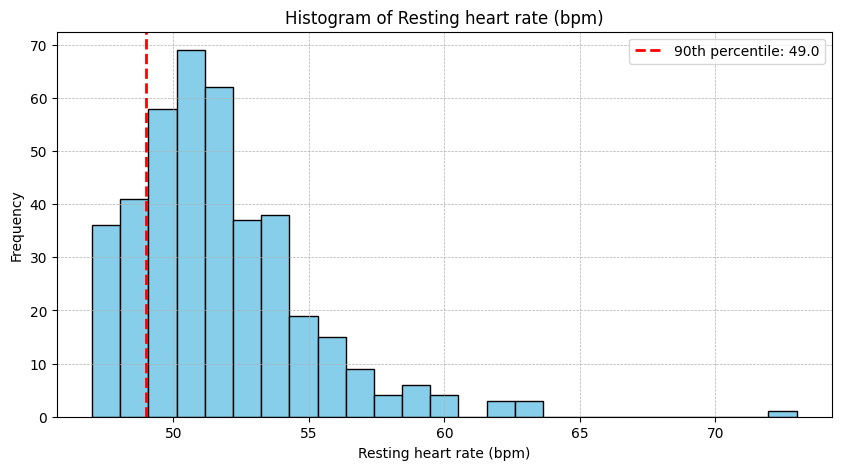

In [30]:
# Compute the 90th percentile for "Resting heart rate (bpm)"
threshold_rhr = df['Resting heart rate (bpm)'].quantile(0.1)

# Visualizing the histogram for "Resting heart rate (bpm)" with the 90th percentile line
plt.figure(figsize=(10,5))
plt.hist(df['Resting heart rate (bpm)'], bins=25, color='skyblue', edgecolor='black')
plt.axvline(threshold_rhr, color='red', linestyle='dashed', linewidth=2, label=f'90th percentile: {threshold_rhr}')
plt.title('Histogram of Resting heart rate (bpm)')
plt.xlabel('Resting heart rate (bpm)')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


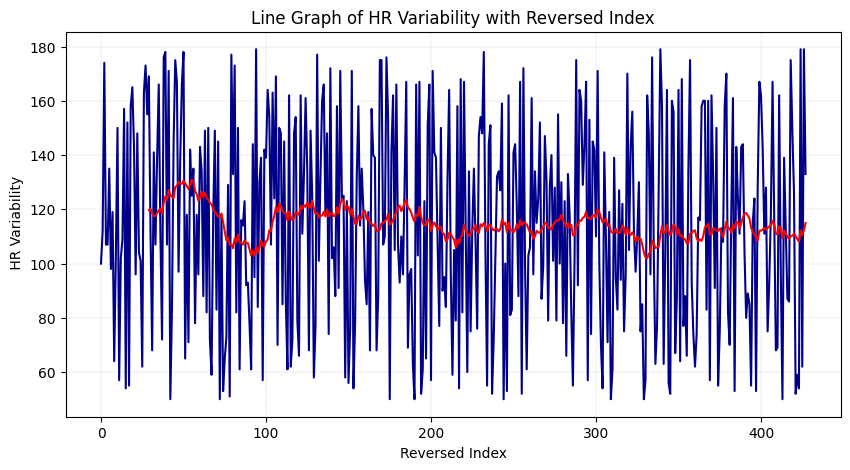

In [53]:
# Calculate the 30-period rolling average for "Heart rate variability (ms)"
rolling_avg = df['Resting heart rate (bpm)'].rolling(window=30).mean()

# Create a line graph with reversed order for x-axis (index)
plt.figure(figsize=(10,5))
plt.plot(df.index[::-1], df['Resting heart rate (bpm)'][::-1], '-', color='darkblue')
plt.plot(df.index[::-1], rolling_avg[::-1], '-', color='red', label='30-period smoothed line')
plt.title('Line Graph of HR Variability with Reversed Index')
plt.xlabel('Reversed Index')
plt.ylabel(' HR Variability')
plt.grid(True, which='both', linestyle='--', linewidth=0.2)
plt.show()

In [22]:
threshold = df['Resting heart rate (bpm)'].quantile(0.9)
threshold

56.0

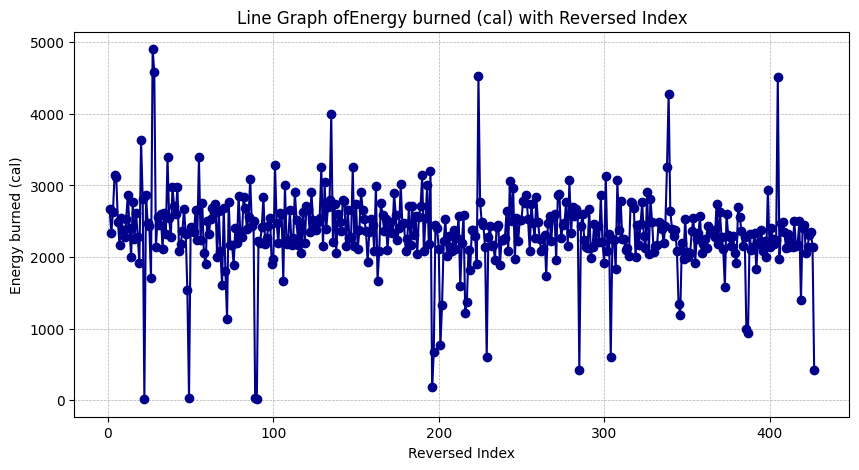

In [33]:
# Create a line graph with reversed order for x-axis (index)
plt.figure(figsize=(10,5))
plt.plot(df.index[::-1], df['Energy burned (cal)'][::-1], '-o', color='darkblue')
plt.title('Line Graph ofEnergy burned (cal) with Reversed Index')
plt.xlabel('Reversed Index')
plt.ylabel('Energy burned (cal)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [36]:
# Adjusting the sample data generation to match the length of your dataframe
df_length = len(df)  # Get the length of your dataframe

# Adjusted Sample data generation
np.random.seed(42)
for col in columns_of_interest:
    if " %" in col:
        df[col] = np.random.randint(50, 100, df_length)
    elif "(bpm)" in col:
        df[col] = np.random.randint(50, 180, df_length)
    elif "(celsius)" in col:
        df[col] = np.random.uniform(34, 37, df_length)
    elif "(ms)" in col:
        df[col] = np.random.randint(50, 150, df_length)
    else:
        df[col] = np.random.randint(10, 200, df_length)

# Calculating coefficient of variation for each column
cv_values_corrected = {}
for col in columns_of_interest:
    mean_value = df[col].mean()
    std_value = df[col].std()
    cv_values_corrected[col] = (std_value / mean_value) * 100

# Sorting the columns based on adjusted CV values
sorted_cv_values_corrected = dict(sorted(cv_values_corrected.items(), key=lambda item: item[1], reverse=True))

sorted_cv_values_corrected


{'Sleep debt (min)': 53.37960684345162,
 'REM duration (min)': 53.30675760036128,
 'Deep (SWS) duration (min)': 52.71788641403442,
 'Sleep need (min)': 52.606076565074474,
 'Day Strain': 52.574781406459905,
 'Awake duration (min)': 51.873830699920056,
 'Light sleep duration (min)': 51.7196849066267,
 'In bed duration (min)': 51.68832366596079,
 'Respiratory rate (rpm)': 50.69513960036575,
 'Asleep duration (min)': 50.29070432104872,
 'Energy burned (cal)': 49.36416740032726,
 'Resting heart rate (bpm)': 33.53866139285493,
 'Max HR (bpm)': 32.654561039863005,
 'Average HR (bpm)': 31.85483828743147,
 'Heart rate variability (ms)': 28.95228186642637,
 'Blood oxygen %': 20.001169162710564,
 'Sleep performance %': 19.819386357060765,
 'Recovery score %': 19.08088720734748,
 'Sleep efficiency %': 18.802186598726937,
 'Skin temp (celsius)': 2.455044386440904}

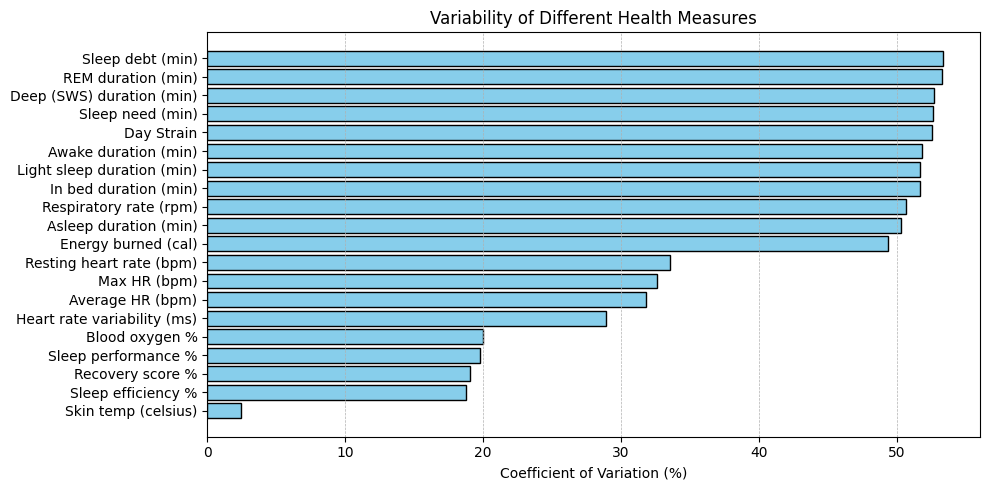

In [39]:


# Plotting the coefficient of variation values as a bar graph
plt.figure(figsize=(10,5))
plt.barh(list(sorted_cv_values_corrected.keys()), sorted_cv_values_corrected.values(), color='skyblue', edgecolor='black')
plt.xlabel('Coefficient of Variation (%)')
plt.title('Variability of Different Health Measures')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest CV at the top
plt.grid(True, which='both', linestyle='--', linewidth=0.5, axis='x')
plt.tight_layout()
plt.show()

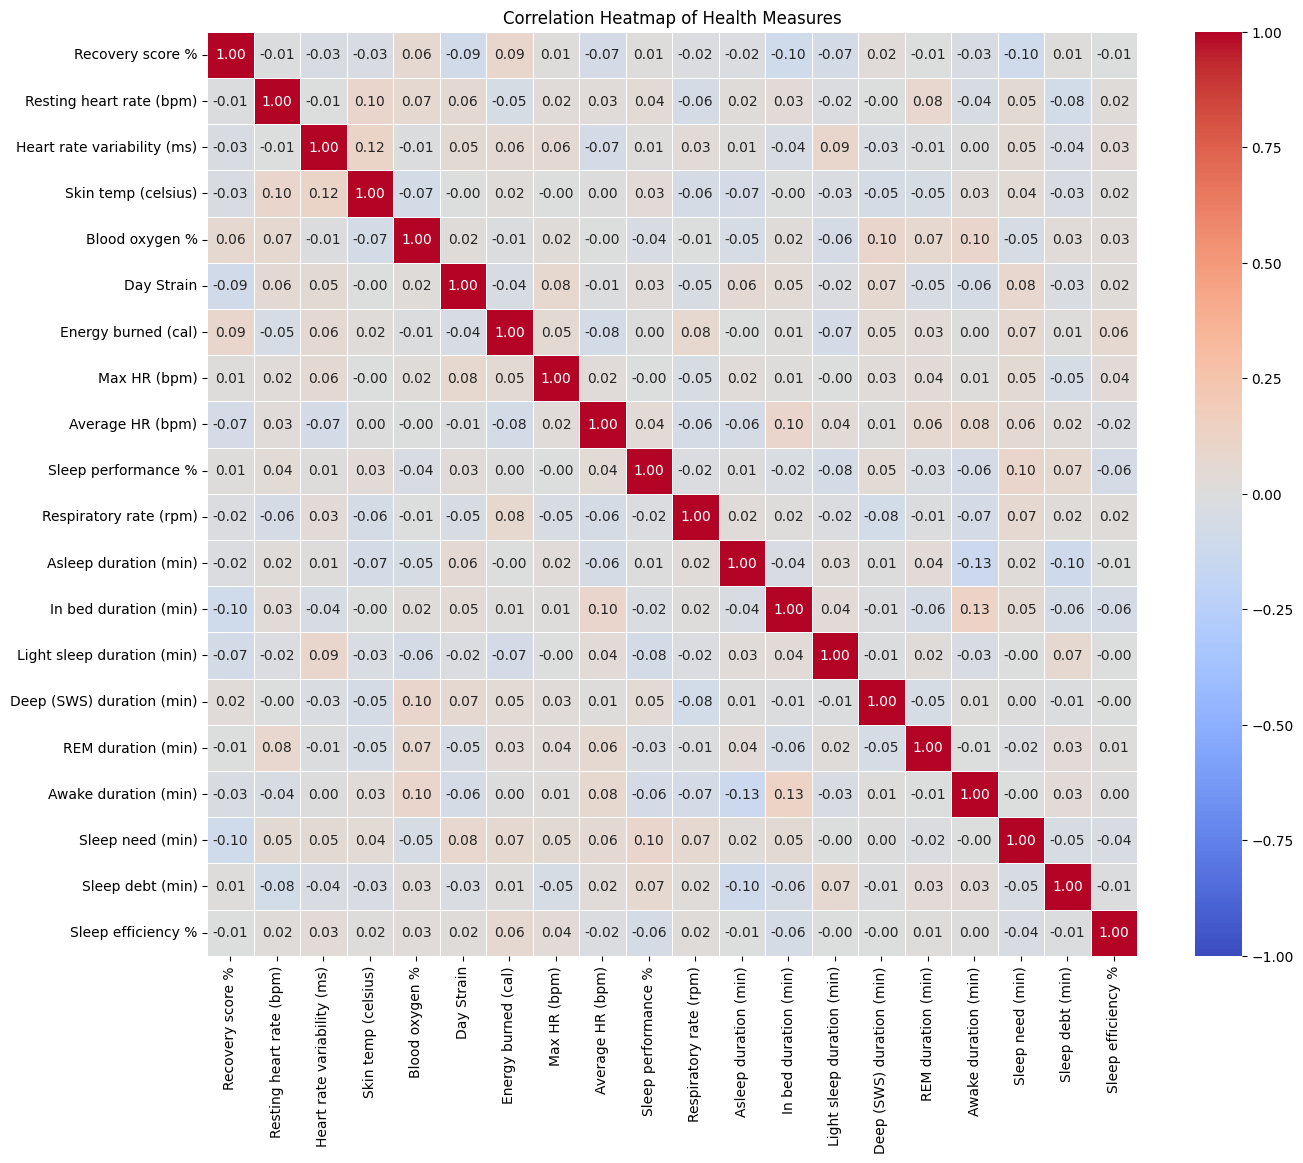

In [57]:
import seaborn as sns

# Sample data generation for demonstration purposes
columns_of_interest = [
    "Recovery score %", "Resting heart rate (bpm)", "Heart rate variability (ms)", 
    "Skin temp (celsius)", "Blood oxygen %", "Day Strain", "Energy burned (cal)", 
    "Max HR (bpm)", "Average HR (bpm)", "Sleep performance %", "Respiratory rate (rpm)", 
    "Asleep duration (min)", "In bed duration (min)", "Light sleep duration (min)", 
    "Deep (SWS) duration (min)", "REM duration (min)", "Awake duration (min)", 
    "Sleep need (min)", "Sleep debt (min)", "Sleep efficiency %"
]


# Calculate the correlation matrix for the columns of interest
correlation_matrix = df[columns_of_interest].corr()

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Health Measures')
plt.show()


In [69]:
correlation_matrix.head()

,Recovery score %,Resting heart rate (bpm),Heart rate variability (ms),Skin temp (celsius),Blood oxygen %,Day Strain,Energy burned (cal),Max HR (bpm),Average HR (bpm),Sleep performance %,Respiratory rate (rpm),Asleep duration (min),In bed duration (min),Light sleep duration (min),Deep (SWS) duration (min),REM duration (min),Awake duration (min),Sleep need (min),Sleep debt (min),Sleep efficiency %
Recovery score %,1.000000,-0.014089,-0.032887,-0.032199,0.064223,-0.092146,0.085982,0.008568,-0.069937,0.011233,-0.022030,-0.021794,-0.095019,-0.071029,0.024905,-0.006281,-0.032931,-0.097063,0.008609,-0.006149
Resting heart rate (bpm),-0.014089,1.000000,-0.005287,0.097278,0.068555,0.055188,-0.050325,0.024684,0.030642,0.043289,-0.060836,0.023132,0.033509,-0.021471,-0.000676,0.080847,-0.039397,0.048579,-0.084281,0.016566
Heart rate variability (ms),-0.032887,-0.005287,1.000000,0.116580,-0.012540,0.054162,0.059557,0.061979,-0.066563,0.009409,0.031507,0.010918,-0.041332,0.086549,-0.030326,-0.011130,0.003078,0.048003,-0.038630,0.032948
Skin temp (celsius),-0.032199,0.097278,0.116580,1.000000,-0.073789,-0.000784,0.019469,-0.002860,0.001231,0.032907,-0.056693,-0.067641,-0.003195,-0.030636,-0.054730,-0.054456,0.025392,0.040233,-0.032978,0.015288
Blood oxygen %,0.064223,0.068555,-0.012540,-0.073789,1.000000,0.020939,-0.013665,0.018240,-0.004334,-0.038383,-0.006536,-0.048894,0.020122,-0.055919,0.095539,0.073774,0.096342,-0.047856,0.030666,0.025789


In [71]:
# Extract non-diagonal elements of the correlation matrix
non_diagonal_elements = correlation_matrix.where(~np.eye(correlation_matrix.shape[0], dtype=bool)).stack()

# Find columns with highest and lowest correlations
max_corr_value = non_diagonal_elements.max()
min_corr_value = non_diagonal_elements.min()

max_corr_columns = tuple(non_diagonal_elements[non_diagonal_elements == max_corr_value].index[0])
min_corr_columns = tuple(non_diagonal_elements[non_diagonal_elements == min_corr_value].index[0])

max_corr_columns, max_corr_value, min_corr_columns, min_corr_value


(('In bed duration (min)', 'Awake duration (min)'),
 0.1267442349356106,
 ('Asleep duration (min)', 'Awake duration (min)'),
 -0.1284862486514028)

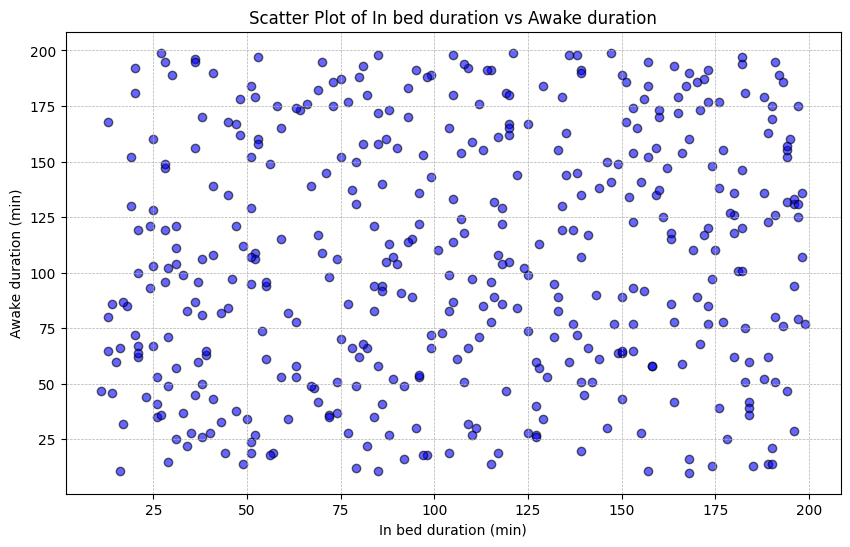

In [72]:
# Scatter plot for 'In bed duration (min)' vs 'Awake duration (min)'
plt.figure(figsize=(10,6))
plt.scatter(df['In bed duration (min)'], df['Awake duration (min)'], color='blue', edgecolor='black', alpha=0.6)
plt.title('Scatter Plot of In bed duration vs Awake duration')
plt.xlabel('In bed duration (min)')
plt.ylabel('Awake duration (min)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
